Loading model from: vision_sgd_pretrainedFalse_cosine_model_combined.pth
Model loaded successfully.
Test data loaded successfully.


Scanning for 2 images from each of 15 combinations:  93%|██████████████████████▎ | 68214/73389 [34:16<02:36, 33.17it/s]



-> All required images collected.

Generating Grad-CAM visualizations...


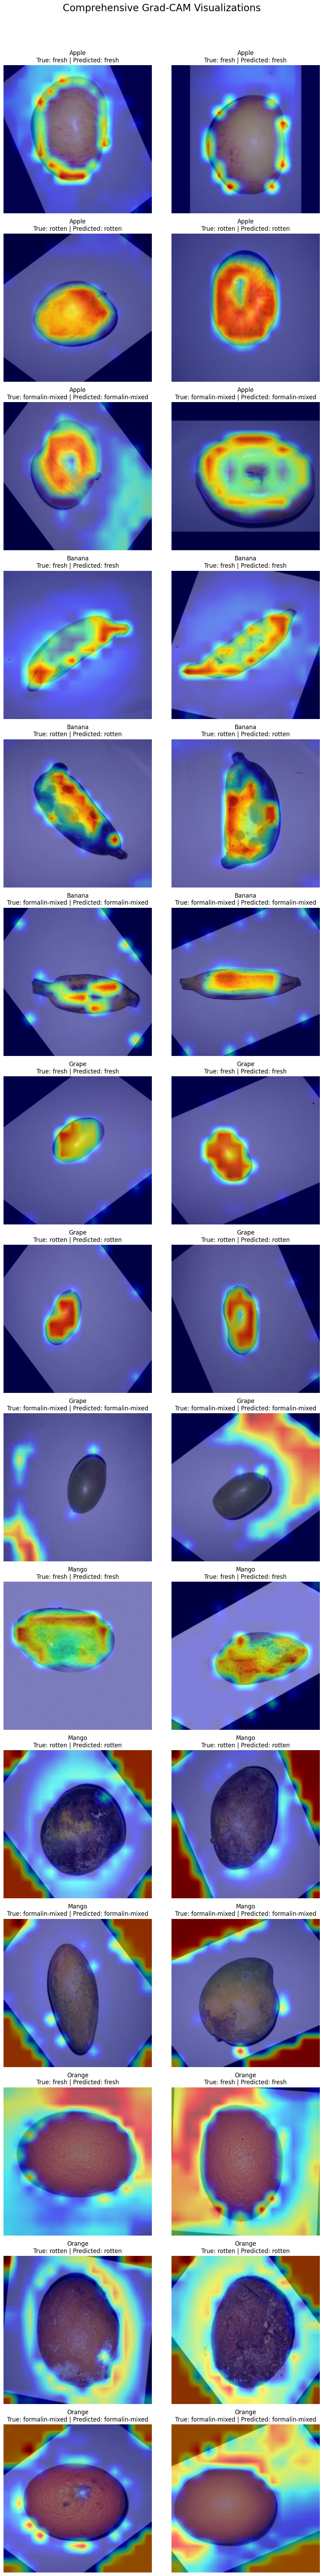

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms, models
from torch.utils.data import DataLoader, random_split, Subset, Dataset
import os
import warnings
from tqdm import tqdm # <--- 1. IMPORT TQDM HERE

# --- IMPORTS for XAI ---
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Suppress warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# =============================================================================
# 1. CLASS DEFINITIONS (Unchanged)
# =============================================================================

class ViTTwoHead(nn.Module):
    def __init__(self, num_fruits=5, num_qualities=3):
        super().__init__()
        self.base_model = models.vit_b_16(weights=None)
        num_ftrs = self.base_model.heads.head.in_features
        self.base_model.heads.head = nn.Identity()
        self.fruit_head = nn.Linear(num_ftrs, num_fruits)
        self.qual_head = nn.Linear(num_ftrs, num_qualities)

    def forward(self, x):
        features = self.base_model(x)
        fruit_out = self.fruit_head(features)
        qual_out = self.qual_head(features)
        return fruit_out, qual_out

class FruitVisionDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        self.fruit_classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.quality_classes = ['fresh', 'rotten', 'formalin-mixed']
        
        for fruit_index, fruit in enumerate(self.fruit_classes):
            fruit_path = os.path.join(root_dir, fruit)
            if not os.path.isdir(fruit_path): continue
            for qual_index, qual in enumerate(self.quality_classes):
                qual_path = os.path.join(fruit_path, qual)
                if not os.path.isdir(qual_path): continue
                for img_file in os.listdir(qual_path):
                    self.samples.append((os.path.join(qual_path, img_file), fruit_index, qual_index))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, fruit_label, qual_label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        plot_image = np.array(image.resize((224, 224))) / 255.0
        if self.transform:
            tensor_image = self.transform(image)
        return tensor_image, plot_image, fruit_label, qual_label

# =============================================================================
# 2. SETUP MODEL AND DATA
# =============================================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = 'vision_sgd_pretrainedFalse_cosine_model_combined.pth'
DATA_DIR = r'D:\Research\Datasets\FruitVision\Augmented-Resized Image'
IMAGE_SIZE = 224

print(f"Loading model from: {MODEL_PATH}")
model = ViTTwoHead(num_fruits=5, num_qualities=3)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
model.to(device).eval()
print("Model loaded successfully.")

val_test_transforms = transforms.Compose([transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
test_dataset = FruitVisionDataset(DATA_DIR, transform=val_test_transforms)

test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
print("Test data loaded successfully.")

# =============================================================================
# 3. GENERATE AND PLOT GRAD-CAM (With Comprehensive Sampling)
# =============================================================================

class ModelWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return self.model(x)[1]

def reshape_transform(tensor):
    result = tensor[:, 1:, :].reshape(tensor.size(0), 14, 14, tensor.size(2))
    result = result.permute(0, 3, 1, 2)
    return result

cam_model = ModelWrapper(model)
target_layers = [model.base_model.encoder.layers[-1].ln_1]
cam = GradCAM(model=cam_model, target_layers=target_layers, reshape_transform=reshape_transform)


def plot_comprehensive_cam_visualizations(model, data_loader, images_per_combo=2):
    fruit_classes = data_loader.dataset.fruit_classes
    quality_classes = data_loader.dataset.quality_classes
    
    images_to_plot = {f_idx: {q_idx: [] for q_idx in range(len(quality_classes))} for f_idx in range(len(fruit_classes))}
    
    total_combos = len(fruit_classes) * len(quality_classes)
    combos_completed = 0
    
    desc = f"Scanning for {images_per_combo} images from each of {total_combos} combinations"
    
    # <--- 2. WRAP THE DATA LOADER WITH TQDM HERE ---
    for tensor_image, plot_image, fruit_label_t, qual_label_t in tqdm(data_loader, desc=desc):
        fruit_label = fruit_label_t.item()
        qual_label = qual_label_t.item()
        
        if len(images_to_plot[fruit_label][qual_label]) < images_per_combo:
            images_to_plot[fruit_label][qual_label].append({
                "tensor": tensor_image,
                "plot_image": plot_image,
            })
            if len(images_to_plot[fruit_label][qual_label]) == images_per_combo:
                combos_completed += 1

        if combos_completed == total_combos:
            print("\n-> All required images collected.")
            break
            
    # --- PLOTTING LOGIC ---
    num_rows = total_combos
    num_cols = images_per_combo
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 5))
    fig.suptitle("Comprehensive Grad-CAM Visualizations", fontsize=20)
    
    print("\nGenerating Grad-CAM visualizations...")
    
    plot_row = 0
    for fruit_idx in sorted(images_to_plot.keys()):
        for qual_idx in sorted(images_to_plot[fruit_idx].keys()):
            items = images_to_plot[fruit_idx][qual_idx]
            for plot_col, item in enumerate(items):
                ax = axes[plot_row, plot_col]
                
                input_tensor = item["tensor"].to(device)
                numpy_plot_image = item["plot_image"].squeeze().numpy()
                
                grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0, :]
                visualization = show_cam_on_image(numpy_plot_image, grayscale_cam, use_rgb=True)

                with torch.no_grad():
                    _, qual_logits = model(input_tensor)
                predicted_class = qual_logits.argmax().item()
                
                fruit_name = fruit_classes[fruit_idx]
                true_name = quality_classes[qual_idx]
                pred_name = quality_classes[predicted_class]
                ax.set_title(f"{fruit_name}\nTrue: {true_name} | Predicted: {pred_name}", fontsize=12)
                ax.imshow(visualization)
                ax.axis('off')
            plot_row += 1
            
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# =============================================================================
# 4. RUN THE VISUALIZATION
# =============================================================================
plot_comprehensive_cam_visualizations(model, test_loader, images_per_combo=2)

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms, models
from torch.utils.data import DataLoader, random_split, Subset, Dataset
import os
import warnings
from tqdm import tqdm

# --- IMPORTS for XAI ---
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Suppress warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# =============================================================================
# 1. CLASS DEFINITIONS (Unchanged)
# =============================================================================

class ViTTwoHead(nn.Module):
    def __init__(self, num_fruits=5, num_qualities=3):
        super().__init__()
        self.base_model = models.vit_b_16(weights=None)
        num_ftrs = self.base_model.heads.head.in_features
        self.base_model.heads.head = nn.Identity()
        self.fruit_head = nn.Linear(num_ftrs, num_fruits)
        self.qual_head = nn.Linear(num_ftrs, num_qualities)

    def forward(self, x):
        features = self.base_model(x)
        fruit_out = self.fruit_head(features)
        qual_out = self.qual_head(features)
        return fruit_out, qual_out

class FruitVisionDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        self.fruit_classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.quality_classes = ['fresh', 'rotten', 'formalin-mixed']
        
        for fruit_index, fruit in enumerate(self.fruit_classes):
            fruit_path = os.path.join(root_dir, fruit)
            if not os.path.isdir(fruit_path): continue
            for qual_index, qual in enumerate(self.quality_classes):
                qual_path = os.path.join(fruit_path, qual)
                if not os.path.isdir(qual_path): continue
                for img_file in os.listdir(qual_path):
                    self.samples.append((os.path.join(qual_path, img_file), fruit_index, qual_index))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, fruit_label, qual_label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        plot_image = np.array(image.resize((224, 224))) / 255.0
        if self.transform:
            tensor_image = self.transform(image)
        return tensor_image, plot_image, fruit_label, qual_label

# =============================================================================
# 2. SETUP MODEL AND DATA
# =============================================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = 'vision_sgd_pretrainedFalse_cosine_model_combined.pth'
DATA_DIR = r'D:\Research\Datasets\FruitVision\Augmented-Resized Image'
IMAGE_SIZE = 224

print(f"Loading model from: {MODEL_PATH}")
model = ViTTwoHead(num_fruits=5, num_qualities=3)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
model.to(device).eval()
print("Model loaded successfully.")

val_test_transforms = transforms.Compose([transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
test_dataset = FruitVisionDataset(DATA_DIR, transform=val_test_transforms)

test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=4, pin_memory=True)
print("Test data loaded successfully. Parallel loading is enabled.")

# =============================================================================
# 3. GENERATE AND PLOT GRAD-CAM (With Side-by-Side Comparison)
# =============================================================================

class ModelWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return self.model(x)[1]

def reshape_transform(tensor):
    result = tensor[:, 1:, :].reshape(tensor.size(0), 14, 14, tensor.size(2))
    result = result.permute(0, 3, 1, 2)
    return result

cam_model = ModelWrapper(model)
target_layers = [model.base_model.encoder.layers[-1].ln_1]
cam = GradCAM(model=cam_model, target_layers=target_layers, reshape_transform=reshape_transform)


def plot_comprehensive_cam_visualizations(model, data_loader, images_per_combo=2):
    fruit_classes = data_loader.dataset.fruit_classes
    quality_classes = data_loader.dataset.quality_classes
    
    images_to_plot = {f_idx: {q_idx: [] for q_idx in range(len(quality_classes))} for f_idx in range(len(fruit_classes))}
    
    total_combos = len(fruit_classes) * len(quality_classes)
    combos_completed = 0
    
    desc = f"Scanning for {images_per_combo} images from each of {total_combos} combinations"
    
    for tensor_image, plot_image, fruit_label_t, qual_label_t in tqdm(data_loader, desc=desc):
        fruit_label = fruit_label_t.item()
        qual_label = qual_label_t.item()
        
        if len(images_to_plot[fruit_label][qual_label]) < images_per_combo:
            images_to_plot[fruit_label][qual_label].append({
                "tensor": tensor_image,
                "plot_image": plot_image,
            })
            if len(images_to_plot[fruit_label][qual_label]) == images_per_combo:
                combos_completed += 1

        if combos_completed == total_combos:
            tqdm.write("\n-> All required images collected.")
            break
            
    # --- PLOTTING LOGIC MODIFIED FOR SIDE-BY-SIDE VIEW ---
    num_rows = total_combos
    # We now need 2 columns for each image (Original + CAM)
    num_cols = images_per_combo * 2
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 4, num_rows * 4))
    fig.suptitle("Comprehensive Grad-CAM Visualizations", fontsize=20)
    
    print("\nGenerating Grad-CAM visualizations...")
    
    plot_row = 0
    for fruit_idx in sorted(images_to_plot.keys()):
        for qual_idx in sorted(images_to_plot[fruit_idx].keys()):
            items = images_to_plot[fruit_idx][qual_idx]
            for i, item in enumerate(items):
                # Calculate the correct columns for this image's Original and CAM plots
                orig_col = i * 2
                cam_col = i * 2 + 1
                
                ax_orig = axes[plot_row, orig_col]
                ax_cam = axes[plot_row, cam_col]
                
                input_tensor = item["tensor"].to(device)
                numpy_plot_image = item["plot_image"].squeeze().numpy()
                
                grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0, :]
                visualization = show_cam_on_image(numpy_plot_image, grayscale_cam, use_rgb=True)

                with torch.no_grad():
                    _, qual_logits = model(input_tensor)
                predicted_class = qual_logits.argmax().item()
                
                fruit_name = fruit_classes[fruit_idx]
                true_name = quality_classes[qual_idx]
                pred_name = quality_classes[predicted_class]

                # Plot Original Image
                ax_orig.imshow(numpy_plot_image)
                ax_orig.set_title(f"{fruit_name} (Original)\nTrue: {true_name}")
                ax_orig.axis('off')
                
                # Plot Grad-CAM Image
                ax_cam.imshow(visualization)
                ax_cam.set_title(f"{fruit_name} (Grad-CAM)\nPredicted: {pred_name}")
                ax_cam.axis('off')

            plot_row += 1
            
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# =============================================================================
# 4. RUN THE VISUALIZATION
# =============================================================================
plot_comprehensive_cam_visualizations(model, test_loader, images_per_combo=2)

Loading model from: vision_sgd_pretrainedFalse_cosine_model_combined.pth
Model loaded successfully.
Test data loaded successfully. Parallel loading is enabled.


Scanning for 2 images from each of 15 combinations:   0%|                                    | 0/73389 [00:00<?, ?it/s]